In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from peft import LoraConfig, get_peft_model, TaskType

from dataclasses import dataclass
from typing import Optional, Dict, Any, List
import re
from sklearn.metrics import mean_absolute_error, cohen_kappa_score

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModel,   # thêm dòng này
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)
from collections import Counter

In [4]:
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
TRAIN_CSV = "/content/ielts_train_aug_df.csv"
VAL_CSV   = "/content/ielts_evals_aug_df.csv"
TEST_CSV  = "/content/ielts_test_locked_df.csv"

MAX_LENGTH = 2048
SEED = 42

BATCH_SIZE = 6
GRAD_ACCUM = 4

LR = 4e-5
EPOCHS = 20
WEIGHT_DECAY = 0.01
OUTPUT_DIR = "./qwen25_3b_ielts_4criteria"

TARGET_COLS = ["TR", "CC", "LR", "GRA"]

# 11 band levels: 4.0 -> 9.0 step 0.5
NUM_BINS = 11
NUM_THRESHOLDS = NUM_BINS - 1

SCORE_MIN = 4.0
SCORE_MAX = 9.0
SCORE_STEP = 0.5

set_seed(SEED)

TR_FEATURE_COLS = [
    "tr_prompt_essay_sim",
    "tr_prompt_keyword_coverage",
    "tr_has_opinion",
    "tr_has_both_views",
    "tr_has_example",
    "tr_has_conclusion",
    "tr_word_count",
]

CC_FEATURE_COLS = [
    "cc_num_paragraphs",
    "cc_avg_paragraph_len",
    "cc_avg_sentence_len",
    "cc_sentence_len_std",
    "cc_discourse_marker_count",
    "cc_discourse_marker_diversity",
]

LR_FEATURE_COLS = [
    "lr_root_ttr",
    "lr_avg_word_len",
    "lr_long_word_ratio",
    "lr_repetition_ratio",
    "lr_unique_word_ratio",
    "lr_lexical_density_proxy",
]

GRA_FEATURE_COLS = [
    "gf_word_count",
    "gf_sentence_count",
    "gf_avg_sentence_len",
    "gf_short_sentence_ratio",
    "gf_long_sentence_ratio",
    "gf_punct_density",
    "gf_repeated_punct_ratio",
    "gf_lowercase_sent_start_ratio",
    "gf_lowercase_i_ratio",
    "gf_repeated_word_ratio",
    "gf_missing_terminal_punct",
]

CRITERION_WEIGHTS = [1.0, 1.0, 1.0, 1.0]
HEAD_DROPOUT = 0.1
BIAS_LOSS_WEIGHT = 0.02
ORDINAL_LOSS_NAME = "bce_with_logits"

In [5]:
STOPWORDS = {
    "a","an","the","and","or","but","if","while","is","am","are","was","were",
    "be","been","being","of","to","in","on","for","with","as","at","by","from",
    "that","this","these","those","it","its","he","she","they","them","their",
    "we","our","you","your","i","me","my","mine","his","her","hers","do","does",
    "did","have","has","had","will","would","can","could","should","may","might",
    "not","so","than","then","there","here","about","into","over","after","before",
    "more","most","some","any","such","no","nor","too","very"
}

DISCOURSE_MARKERS = [
    "however", "therefore", "moreover", "furthermore", "in addition",
    "for example", "for instance", "on the one hand", "on the other hand",
    "in conclusion", "to conclude", "in summary", "as a result",
    "firstly", "secondly", "finally", "besides", "nevertheless",
    "thus", "overall", "in contrast", "for this reason"
]

LONG_WORD_MIN_LEN = 7

def safe_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def normalize_text(text):
    text = safe_text(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_words(text):
    text = normalize_text(text)
    return re.findall(r"[a-zA-Z']+", text)

def split_sentences(text):
    text = safe_text(text).strip()
    if not text:
        return []
    sents = re.split(r'(?<=[.!?])\s+', text)
    sents = [s.strip() for s in sents if s.strip()]
    return sents

def split_paragraphs(text):
    text = safe_text(text)
    paras = [p.strip() for p in re.split(r"\n\s*\n+", text) if p.strip()]
    if len(paras) == 0 and text.strip():
        paras = [text.strip()]
    return paras

def word_count(text):
    return len(tokenize_words(text))

def sentence_count(text):
    return len(split_sentences(text))

def unique_ratio(words):
    if len(words) == 0:
        return 0.0
    return len(set(words)) / len(words)

def root_ttr(words):
    if len(words) == 0:
        return 0.0
    return len(set(words)) / math.sqrt(len(words))

def repetition_ratio(words):
    if len(words) <= 1:
        return 0.0
    c = Counter(words)
    repeated = sum(v for v in c.values() if v > 1)
    return repeated / len(words)

def repeated_word_ratio(words):
    if len(words) <= 1:
        return 0.0
    repeated_pairs = 0
    for i in range(1, len(words)):
        if words[i] == words[i - 1]:
            repeated_pairs += 1
    return repeated_pairs / len(words)

def avg_word_len(words):
    if len(words) == 0:
        return 0.0
    return float(np.mean([len(w) for w in words]))

def lexical_density_proxy(words):
    if len(words) == 0:
        return 0.0
    content_like = [w for w in words if len(w) > 3 and w not in STOPWORDS]
    return len(content_like) / len(words)

def long_word_ratio(words, min_len=LONG_WORD_MIN_LEN):
    if len(words) == 0:
        return 0.0
    return sum(len(w) >= min_len for w in words) / len(words)

def sentence_lengths(sentences):
    return [len(tokenize_words(s)) for s in sentences if len(tokenize_words(s)) > 0]

def count_discourse_markers(text):
    low = normalize_text(text)
    counts = []
    found = 0
    found_types = 0
    for m in DISCOURSE_MARKERS:
        c = low.count(m)
        counts.append(c)
        if c > 0:
            found += c
            found_types += 1
    return found, found_types

def prompt_keywords(prompt):
    words = tokenize_words(prompt)
    words = [w for w in words if w not in STOPWORDS and len(w) > 2]
    return set(words)

def jaccard_coverage(prompt, essay):
    pk = prompt_keywords(prompt)
    ew = set(tokenize_words(essay))
    if len(pk) == 0:
        return 0.0
    return len(pk & ew) / len(pk)

def prompt_essay_similarity(prompt, essay):
    pw = prompt_keywords(prompt)
    ew = set([w for w in tokenize_words(essay) if w not in STOPWORDS and len(w) > 2])
    if len(pw) == 0 or len(ew) == 0:
        return 0.0
    return len(pw & ew) / math.sqrt(len(pw) * len(ew))

def has_opinion_statement(text):
    low = normalize_text(text)
    patterns = [
        "i believe", "i think", "in my opinion", "personally",
        "from my perspective", "it seems to me", "i would argue"
    ]
    return float(any(p in low for p in patterns))

def has_both_views(text):
    low = normalize_text(text)
    left = any(p in low for p in ["on the one hand", "some people think", "some people believe"])
    right = any(p in low for p in ["on the other hand", "others think", "others believe", "however"])
    return float(left and right)

def has_example(text):
    low = normalize_text(text)
    patterns = ["for example", "for instance", "such as"]
    return float(any(p in low for p in patterns))

def has_conclusion(text):
    low = normalize_text(text)
    patterns = ["in conclusion", "to conclude", "to sum up", "overall", "in summary"]
    return float(any(p in low for p in patterns))

def repeated_punct_ratio(text):
    if not text:
        return 0.0
    repeated = re.findall(r"([!?.,;:])\1+", text)
    return len(repeated) / max(len(text), 1)

def punct_density(text):
    if not text:
        return 0.0
    puncts = re.findall(r"[.!?,;:]", text)
    words = tokenize_words(text)
    return len(puncts) / max(len(words), 1)

def lowercase_sentence_start_ratio(text):
    sents = split_sentences(text)
    if len(sents) == 0:
        return 0.0
    bad = 0
    total = 0
    for s in sents:
        m = re.search(r"[A-Za-z]", s)
        if m:
            total += 1
            ch = s[m.start()]
            if ch.islower():
                bad += 1
    return bad / total if total > 0 else 0.0

def lowercase_i_ratio(text):
    tokens = re.findall(r"\b[iI]\b", safe_text(text))
    if len(tokens) == 0:
        return 0.0
    bad = sum(1 for t in tokens if t == "i")
    return bad / len(tokens)

def missing_terminal_punct(text):
    text = safe_text(text).strip()
    if not text:
        return 1.0
    return float(text[-1] not in ".!?")

In [6]:
def extract_tr_features(prompt, essay):
    return {
        "tr_prompt_essay_sim": float(prompt_essay_similarity(prompt, essay)),
        "tr_prompt_keyword_coverage": float(jaccard_coverage(prompt, essay)),
        "tr_has_opinion": float(has_opinion_statement(essay)),
        "tr_has_both_views": float(has_both_views(essay)),
        "tr_has_example": float(has_example(essay)),
        "tr_has_conclusion": float(has_conclusion(essay)),
        "tr_word_count": float(word_count(essay)),
    }

def extract_cc_features(prompt, essay):
    paras = split_paragraphs(essay)
    sents = split_sentences(essay)
    sent_lens = sentence_lengths(sents)
    dm_count, dm_div = count_discourse_markers(essay)

    para_lens = [word_count(p) for p in paras] if len(paras) > 0 else [0]

    return {
        "cc_num_paragraphs": float(len(paras)),
        "cc_avg_paragraph_len": float(np.mean(para_lens)) if len(para_lens) > 0 else 0.0,
        "cc_avg_sentence_len": float(np.mean(sent_lens)) if len(sent_lens) > 0 else 0.0,
        "cc_sentence_len_std": float(np.std(sent_lens)) if len(sent_lens) > 0 else 0.0,
        "cc_discourse_marker_count": float(dm_count),
        "cc_discourse_marker_diversity": float(dm_div),
    }

def extract_lr_features(prompt, essay):
    words = tokenize_words(essay)

    return {
        "lr_root_ttr": float(root_ttr(words)),
        "lr_avg_word_len": float(avg_word_len(words)),
        "lr_long_word_ratio": float(long_word_ratio(words)),
        "lr_repetition_ratio": float(repetition_ratio(words)),
        "lr_unique_word_ratio": float(unique_ratio(words)),
        "lr_lexical_density_proxy": float(lexical_density_proxy(words)),
    }

def extract_gra_features(prompt, essay):
    words = tokenize_words(essay)
    sents = split_sentences(essay)
    sent_lens = sentence_lengths(sents)

    return {
        "gf_word_count": float(len(words)),
        "gf_sentence_count": float(len(sents)),
        "gf_avg_sentence_len": float(np.mean(sent_lens)) if len(sent_lens) > 0 else 0.0,
        "gf_short_sentence_ratio": float(sum(l < 8 for l in sent_lens) / len(sent_lens)) if len(sent_lens) > 0 else 0.0,
        "gf_long_sentence_ratio": float(sum(l > 30 for l in sent_lens) / len(sent_lens)) if len(sent_lens) > 0 else 0.0,
        "gf_punct_density": float(punct_density(essay)),
        "gf_repeated_punct_ratio": float(repeated_punct_ratio(essay)),
        "gf_lowercase_sent_start_ratio": float(lowercase_sentence_start_ratio(essay)),
        "gf_lowercase_i_ratio": float(lowercase_i_ratio(essay)),
        "gf_repeated_word_ratio": float(repeated_word_ratio(words)),
        "gf_missing_terminal_punct": float(missing_terminal_punct(essay)),
    }

In [7]:
def add_all_features(df):
    if df is None:
        return None

    df = df.copy()
    df["prompt"] = df["prompt"].apply(safe_text)
    df["essay"] = df["essay"].apply(safe_text)

    tr_rows = []
    cc_rows = []
    lr_rows = []
    gra_rows = []

    for _, row in df.iterrows():
        prompt = row["prompt"]
        essay = row["essay"]

        tr_rows.append(extract_tr_features(prompt, essay))
        cc_rows.append(extract_cc_features(prompt, essay))
        lr_rows.append(extract_lr_features(prompt, essay))
        gra_rows.append(extract_gra_features(prompt, essay))

    tr_df = pd.DataFrame(tr_rows)
    cc_df = pd.DataFrame(cc_rows)
    lr_df = pd.DataFrame(lr_rows)
    gra_df = pd.DataFrame(gra_rows)

    df = pd.concat([df.reset_index(drop=True), tr_df, cc_df, lr_df, gra_df], axis=1)
    return df

In [9]:
# 1. Load dữ liệu gốc
train_df = pd.read_csv(TRAIN_CSV, engine="python", on_bad_lines="skip")
val_df = pd.read_csv(VAL_CSV, engine="python", on_bad_lines="skip") if os.path.exists(VAL_CSV) else None
test_df = pd.read_csv(TEST_CSV, engine="python", on_bad_lines="skip") if os.path.exists(TEST_CSV) else None

# 2. Tách validation nếu chưa có
if val_df is None:
    from sklearn.model_selection import train_test_split
    train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=SEED)

In [10]:
train_df = add_all_features(train_df)
val_df = add_all_features(val_df)
if test_df is not None:
    test_df = add_all_features(test_df)

print("Train columns added ok:", len(train_df.columns))
print(train_df[
    TR_FEATURE_COLS[:3] + CC_FEATURE_COLS[:3] + LR_FEATURE_COLS[:3] + GRA_FEATURE_COLS[:3]
].head(2))

Train columns added ok: 47
   tr_prompt_essay_sim  tr_prompt_keyword_coverage  tr_has_opinion  \
0             0.112938                    0.357143             0.0   
1             0.180021                    0.500000             0.0   

   cc_num_paragraphs  cc_avg_paragraph_len  cc_avg_sentence_len  lr_root_ttr  \
0                1.0                 284.0            20.285714    10.206322   
1                1.0                 275.0            21.153846     8.502620   

   lr_avg_word_len  lr_long_word_ratio  gf_word_count  gf_sentence_count  \
0         5.468310            0.341549          284.0               14.0   
1         4.785455            0.218182          275.0               13.0   

   gf_avg_sentence_len  
0            20.285714  
1            21.153846  


In [11]:
ALL_FEATURE_COLS = (
    TR_FEATURE_COLS +
    CC_FEATURE_COLS +
    LR_FEATURE_COLS +
    GRA_FEATURE_COLS
)

needed_cols = ["prompt", "essay"] + TARGET_COLS + ALL_FEATURE_COLS

def robust_clean_df(df):
    if df is None:
        return None

    df = df.copy()

    missing_cols = [c for c in needed_cols if c not in df.columns]
    if len(missing_cols) > 0:
        raise ValueError(f"Thiếu cột trong CSV: {missing_cols}")

    df = df[needed_cols].copy()

    for col in TARGET_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in ALL_FEATURE_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=TARGET_COLS + ALL_FEATURE_COLS).reset_index(drop=True)

    df["prompt"] = df["prompt"].astype(str).str.strip()
    df["essay"] = df["essay"].astype(str).str.strip()

    df = df[(df["prompt"].str.len() > 0) & (df["essay"].str.len() > 20)].reset_index(drop=True)

    for col in TARGET_COLS:
        df[col] = df[col].clip(SCORE_MIN, SCORE_MAX)

    return df

train_df = robust_clean_df(train_df)
val_df = robust_clean_df(val_df)
test_df = robust_clean_df(test_df)

print(f"Train shape: {train_df.shape if train_df is not None else 0}")
print(f"Val shape: {val_df.shape if val_df is not None else 0}")
if test_df is not None:
    print(f"Test shape: {test_df.shape}")
print(train_df[TARGET_COLS].head())

Train shape: (7520, 36)
Val shape: (998, 36)
Test shape: (802, 36)
    TR   CC   LR  GRA
0  6.0  6.0  5.5  6.0
1  7.0  7.0  7.0  7.0
2  7.0  6.0  6.0  6.0
3  7.0  7.0  7.0  7.0
4  5.5  6.0  6.0  6.0


In [12]:
def build_input_text(row):
    prompt = str(row["prompt"]).strip()
    essay = str(row["essay"]).strip()

    return (
        "You are an IELTS Writing examiner. "
        "Assess the essay based on four criteria: "
        "Task Response (TR), Coherence and Cohesion (CC), "
        "Lexical Resource (LR), and Grammatical Range and Accuracy (GRA).\n\n"
        "[PROMPT]\n"
        f"{prompt}\n\n"
        "[ESSAY]\n"
        f"{essay}"
    )

train_df["text"] = train_df.apply(build_input_text, axis=1)
val_df["text"] = val_df.apply(build_input_text, axis=1)
if test_df is not None:
    test_df["text"] = test_df.apply(build_input_text, axis=1)

def standardize_feature_group(train_df, val_df, test_df, cols, out_col):
    train_arr = train_df[cols].values.astype(np.float32)
    val_arr = val_df[cols].values.astype(np.float32)

    mean_ = train_arr.mean(axis=0)
    std_ = train_arr.std(axis=0)
    std_ = np.where(std_ < 1e-6, 1.0, std_)

    train_arr = (train_arr - mean_) / std_
    val_arr = (val_arr - mean_) / std_

    train_df[out_col] = train_arr.tolist()
    val_df[out_col] = val_arr.tolist()

    if test_df is not None:
        test_arr = test_df[cols].values.astype(np.float32)
        test_arr = (test_arr - mean_) / std_
        test_df[out_col] = test_arr.tolist()

    return mean_, std_

tr_feat_mean, tr_feat_std = standardize_feature_group(train_df, val_df, test_df, TR_FEATURE_COLS, "tr_features")
cc_feat_mean, cc_feat_std = standardize_feature_group(train_df, val_df, test_df, CC_FEATURE_COLS, "cc_features")
lr_feat_mean, lr_feat_std = standardize_feature_group(train_df, val_df, test_df, LR_FEATURE_COLS, "lr_features")
gra_feat_mean, gra_feat_std = standardize_feature_group(train_df, val_df, test_df, GRA_FEATURE_COLS, "gra_features")

def make_labels(df):
    df = df.copy()
    df["labels"] = df[TARGET_COLS].astype(np.float32).values.tolist()
    return df

train_df = make_labels(train_df)
val_df = make_labels(val_df)
if test_df is not None:
    test_df = make_labels(test_df)

print("Prepared text + labels + grouped features")
print(train_df[["text", "labels", "tr_features", "cc_features", "lr_features", "gra_features"]].head(1))

Prepared text + labels + grouped features
                                                text                labels  \
0  You are an IELTS Writing examiner. Assess the ...  [6.0, 6.0, 5.5, 6.0]   

                                         tr_features  \
0  [-1.171739935874939, -0.9477033615112305, -1.0...   

                                         cc_features  \
0  [-0.20861265063285828, -0.09218420088291168, -...   

                                         lr_features  \
0  [0.8060708045959473, 1.6709918975830078, 1.449...   

                                        gra_features  
0  [-0.3001305162906647, 0.03021780587732792, -0....  


In [13]:
dataset_cols = ["text", "labels", "tr_features", "cc_features", "lr_features", "gra_features"]

train_ds = Dataset.from_pandas(train_df[dataset_cols], preserve_index=False)
val_ds = Dataset.from_pandas(val_df[dataset_cols], preserve_index=False)

dataset_dict = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
})

if test_df is not None:
    test_ds = Dataset.from_pandas(test_df[dataset_cols], preserve_index=False)
    dataset_dict["test"] = test_ds

In [14]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

tokenized_ds = dataset_dict.map(tokenize_fn, batched=True)
tokenized_ds = tokenized_ds.remove_columns(["text"])
tokenized_ds.set_format(type="torch")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/7520 [00:00<?, ? examples/s]

Map:   0%|          | 0/998 [00:00<?, ? examples/s]

Map:   0%|          | 0/802 [00:00<?, ? examples/s]

In [15]:
class QwenForIELTSMultiTask(nn.Module):
    def __init__(self, model_name: str, tokenizer, head_dropout: float = 0.1):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.config.pad_token_id = tokenizer.pad_token_id

        self.backbone = AutoModel.from_pretrained(
            model_name,
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        )
        self.backbone.config.pad_token_id = tokenizer.pad_token_id
        self.backbone.config.use_cache = False

        lora_config = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=8,
            lora_alpha=16,
            lora_dropout=0.1,
            bias="none",
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        )
        self.backbone = get_peft_model(self.backbone, lora_config)

        hidden_size = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(head_dropout)

        self.tr_feat_dim = len(TR_FEATURE_COLS)
        self.cc_feat_dim = len(CC_FEATURE_COLS)
        self.lr_feat_dim = len(LR_FEATURE_COLS)
        self.gra_feat_dim = len(GRA_FEATURE_COLS)

        # ===== TR =====
        self.tr_llm_head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(256, 1),
        )
        self.tr_feat_head = nn.Sequential(
            nn.Linear(self.tr_feat_dim, 64),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(64, 1),
        )
        self.tr_gate = nn.Sequential(
            nn.Linear(hidden_size + self.tr_feat_dim, 128),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(128, 1),
        )

        # ===== CC =====
        self.cc_llm_head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(256, 1),
        )
        self.cc_feat_head = nn.Sequential(
            nn.Linear(self.cc_feat_dim, 64),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(64, 1),
        )
        self.cc_gate = nn.Sequential(
            nn.Linear(hidden_size + self.cc_feat_dim, 128),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(128, 1),
        )

        # ===== LR =====
        self.lr_llm_head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(256, 1),
        )
        self.lr_feat_head = nn.Sequential(
            nn.Linear(self.lr_feat_dim, 64),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(64, 1),
        )
        self.lr_gate = nn.Sequential(
            nn.Linear(hidden_size + self.lr_feat_dim, 128),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(128, 1),
        )

        # ===== GRA =====
        self.gra_llm_head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(256, 1),
        )
        self.gra_feat_head = nn.Sequential(
            nn.Linear(self.gra_feat_dim, 64),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(64, 1),
        )
        self.gra_gate = nn.Sequential(
            nn.Linear(hidden_size + self.gra_feat_dim, 128),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(128, 1),
        )

    def _last_token_pool(self, hidden_states, attention_mask):
        last_token_idx = attention_mask.sum(dim=1) - 1
        last_token_idx = last_token_idx.clamp(min=0)
        batch_idx = torch.arange(hidden_states.size(0), device=hidden_states.device)
        pooled = hidden_states[batch_idx, last_token_idx]
        return pooled

    def _fuse_score(self, pooled, feat, llm_head, feat_head, gate_net):
        llm_score = llm_head(pooled)                     # [B, 1]
        feat_score = feat_head(feat)                    # [B, 1]

        gate_input = torch.cat([pooled, feat], dim=1)   # [B, H + F]
        gate = torch.sigmoid(gate_net(gate_input))      # [B, 1]

        fused_score = gate * llm_score + (1.0 - gate) * feat_score
        return fused_score, gate

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        tr_features=None,
        cc_features=None,
        lr_features=None,
        gra_features=None,
        labels=None,
        **kwargs
    ):
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            **kwargs,
        )

        hidden_states = outputs.last_hidden_state
        pooled = self._last_token_pool(hidden_states, attention_mask)
        pooled = self.dropout(pooled)

        tr_features = tr_features.to(device=pooled.device, dtype=pooled.dtype)
        cc_features = cc_features.to(device=pooled.device, dtype=pooled.dtype)
        lr_features = lr_features.to(device=pooled.device, dtype=pooled.dtype)
        gra_features = gra_features.to(device=pooled.device, dtype=pooled.dtype)

        tr, tr_gate = self._fuse_score(
            pooled, tr_features, self.tr_llm_head, self.tr_feat_head, self.tr_gate
        )
        cc, cc_gate = self._fuse_score(
            pooled, cc_features, self.cc_llm_head, self.cc_feat_head, self.cc_gate
        )
        lr, lr_gate = self._fuse_score(
            pooled, lr_features, self.lr_llm_head, self.lr_feat_head, self.lr_gate
        )
        gra, gra_gate = self._fuse_score(
            pooled, gra_features, self.gra_llm_head, self.gra_feat_head, self.gra_gate
        )

        combined_logits = torch.cat([tr, cc, lr, gra], dim=1)

        return {
            "logits": combined_logits,
            "reg_logits": combined_logits,

            # để debug xem model đang tin LLM hay features
            "tr_gate": tr_gate,
            "cc_gate": cc_gate,
            "lr_gate": lr_gate,
            "gra_gate": gra_gate,
        }


model = QwenForIELTSMultiTask(MODEL_NAME, tokenizer, head_dropout=HEAD_DROPOUT)
model.backbone.print_trainable_parameters()
print("Heads + gates are trainable by default.")

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

trainable params: 3,686,400 || all params: 3,089,625,088 || trainable%: 0.1193
Heads + gates are trainable by default.


In [16]:
import torch
import torch.nn as nn
from transformers import Trainer

class IELTSMultiTaskTrainer(Trainer):
    def __init__(
        self,
        *args,
        criterion_weights=None,
        bias_loss_weight=0.02,
        **kwargs
    ):
        super().__init__(*args, **kwargs)

        if criterion_weights is None:
            criterion_weights = [1.0, 1.0, 1.0, 1.0]

        self.criterion_weights = torch.tensor(criterion_weights, dtype=torch.float32)
        self.bias_loss_weight = bias_loss_weight

        # regression cho cả 4 tiêu chí
        self.reg_loss_fn = nn.MSELoss(reduction="none")

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)

        logits = outputs["logits"]   # [B, 4]
        labels = labels.to(logits.dtype)

        # loss từng tiêu chí
        per_dim_loss = self.reg_loss_fn(logits, labels)  # [B, 4]

        weights = self.criterion_weights.to(
            device=logits.device,
            dtype=logits.dtype
        ).view(1, -1)  # [1, 4]

        # weighted mean loss
        weighted_loss = (per_dim_loss * weights).sum() / (
            weights.sum().clamp_min(1e-8) * logits.size(0)
        )

        # bias penalty: tránh lệch mean prediction
        pred_mean = logits.mean(dim=0)
        label_mean = labels.mean(dim=0)
        bias_loss = torch.abs(pred_mean - label_mean).mean()

        loss = weighted_loss + self.bias_loss_weight * bias_loss
        return (loss, outputs) if return_outputs else loss

In [17]:
@dataclass
class RegressionCollator:
    tokenizer: Any

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        labels = torch.stack([
            f["labels"] if isinstance(f["labels"], torch.Tensor)
            else torch.tensor(f["labels"], dtype=torch.float)
            for f in features
        ]).float()

        tr_features = torch.stack([
            f["tr_features"] if isinstance(f["tr_features"], torch.Tensor)
            else torch.tensor(f["tr_features"], dtype=torch.float)
            for f in features
        ]).float()

        cc_features = torch.stack([
            f["cc_features"] if isinstance(f["cc_features"], torch.Tensor)
            else torch.tensor(f["cc_features"], dtype=torch.float)
            for f in features
        ]).float()

        lr_features = torch.stack([
            f["lr_features"] if isinstance(f["lr_features"], torch.Tensor)
            else torch.tensor(f["lr_features"], dtype=torch.float)
            for f in features
        ]).float()

        gra_features = torch.stack([
            f["gra_features"] if isinstance(f["gra_features"], torch.Tensor)
            else torch.tensor(f["gra_features"], dtype=torch.float)
            for f in features
        ]).float()

        batch = self.tokenizer.pad(
            [
                {
                    k: v for k, v in f.items()
                    if k not in ["labels", "tr_features", "cc_features", "lr_features", "gra_features"]
                }
                for f in features
            ],
            padding=True,
            return_tensors="pt"
        )

        batch["labels"] = labels
        batch["tr_features"] = tr_features
        batch["cc_features"] = cc_features
        batch["lr_features"] = lr_features
        batch["gra_features"] = gra_features
        return batch

data_collator = RegressionCollator(tokenizer)

In [18]:
def round_to_half(x):
    return np.round(x * 2) / 2

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.asarray(preds, dtype=np.float32)
    labels = np.asarray(labels, dtype=np.float32)

    preds = np.clip(preds, SCORE_MIN, SCORE_MAX)
    labels = np.clip(labels, SCORE_MIN, SCORE_MAX)

    preds_half = round_to_half(preds)

    maes = []
    qwks = []

    for i in range(labels.shape[1]):
        maes.append(mean_absolute_error(labels[:, i], preds_half[:, i]))

        y_true = np.round(labels[:, i] * 2).astype(int)
        y_pred = np.round(preds_half[:, i] * 2).astype(int)

        qwks.append(cohen_kappa_score(y_true, y_pred, weights="quadratic"))

    within_05 = np.mean(np.abs(preds_half - labels) <= 0.5)

    return {
        "mean_mae": float(np.mean(maes)),
        "mean_qwk": float(np.mean(qwks)),
        "tr_qwk": float(qwks[0]),
        "cc_qwk": float(qwks[1]),
        "lr_qwk": float(qwks[2]),
        "gra_qwk": float(qwks[3]),
        "within_0.5_acc": float(within_05),
    }

In [19]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,

    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,

    learning_rate=LR,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    warmup_ratio=0.1,

    load_best_model_at_end=True,
    metric_for_best_model="mean_qwk",
    greater_is_better=True,

    bf16=True,
    fp16=False,

    gradient_checkpointing=False,
    remove_unused_columns=False,
    report_to="none",
    save_total_limit=2,
    max_grad_norm=1.0,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [20]:
from transformers import get_cosine_schedule_with_warmup

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

num_update_steps_per_epoch = max(
    1, math.ceil(len(tokenized_ds["train"]) / (BATCH_SIZE * GRAD_ACCUM))
)

num_training_steps = num_update_steps_per_epoch * EPOCHS

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(num_training_steps * 0.1),
    num_training_steps=num_training_steps
)

In [21]:
trainer = IELTSMultiTaskTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)],
    criterion_weights=CRITERION_WEIGHTS,
    bias_loss_weight=BIAS_LOSS_WEIGHT,
    optimizers=(optimizer, scheduler),
)

In [22]:
from torch.utils.data import DataLoader

debug_loader = DataLoader(
    tokenized_ds["train"],
    batch_size=2,
    collate_fn=data_collator
)

batch = next(iter(debug_loader))
print(batch.keys())
print(batch["labels"])
print(batch["labels"].shape)
print(batch["labels"].dtype)

KeysView({'input_ids': tensor([[  2610,    525,    458,    358,   2749,   9951,  23893,  83632,     13,
          81835,    279,   8895,   3118,    389,   3040,  12890,     25,   5430,
           5949,    320,   2378,    701,   3539,  51361,    323,  83575,  55981,
            320,   3706,    701,  26819,    938,  11765,    320,  20117,    701,
            323,  28837,  37244,    278,  16437,    323,  50175,    320,  46975,
           3593,  42347,   3361,   2828,    921,   8373,   1251,   1744,    429,
           4518,    315,  26160,   9977,   2297,     11,    582,   1184,    311,
           1477,    264,   1616,    311,   3887,    448,    432,     13,   2014,
           1128,  12818,    653,    498,   7503,    476,  28295,   1939,     58,
           9996,   3022,    921,    641,   3213,  10793,     11,   3644,  23867,
            702,   1012,  12308,    264,   2244,   3484,    315,   3687,   6529,
           2163,    279,   1879,     13,  10328,    279,   4522,    315,   1062,
     

In [23]:
trainer.train()

Epoch,Training Loss,Validation Loss,Mean Mae,Mean Qwk,Tr Qwk,Cc Qwk,Lr Qwk,Gra Qwk,Within 0.5 Acc
1,6.108359,1.284760,0.877630,0.471062,0.456848,0.471607,0.467185,0.488607,0.509770
2,4.969402,1.081810,0.799223,0.605617,0.575206,0.594371,0.623709,0.629181,0.542084
3,4.083886,1.092603,0.796593,0.622942,0.614802,0.615033,0.628992,0.632942,0.543587
4,3.798634,0.945199,0.736473,0.671274,0.670573,0.655417,0.672499,0.686604,0.580912
5,3.794865,0.904194,0.729334,0.674954,0.664035,0.653198,0.679260,0.703322,0.583166
6,3.321954,0.899484,0.715180,0.697174,0.691120,0.683063,0.701295,0.713219,0.601453
7,3.025966,0.894124,0.726077,0.677416,0.670109,0.646713,0.689073,0.703770,0.596443
8,3.028152,0.914394,0.717560,0.700156,0.696723,0.679538,0.705762,0.718602,0.599950
9,2.283164,1.022921,0.757014,0.686662,0.680972,0.667155,0.691730,0.706790,0.563377
10,1.892952,1.049965,0.768412,0.677553,0.674142,0.654334,0.692226,0.689511,0.577655


TrainOutput(global_step=3768, training_loss=6.906360750998155, metrics={'train_runtime': 5547.9675, 'train_samples_per_second': 27.109, 'train_steps_per_second': 1.132, 'total_flos': 0.0, 'train_loss': 6.906360750998155, 'epoch': 12.0})

     epoch  eval_loss  eval_mean_qwk  eval_gra_qwk  eval_within_0.5_acc  \
15     1.0   1.284760       0.471062      0.488607             0.509770   
32     2.0   1.081810       0.605617      0.629181             0.542084   
49     3.0   1.092603       0.622942      0.632942             0.543587   
65     4.0   0.945199       0.671274      0.686604             0.580912   
82     5.0   0.904194       0.674954      0.703322             0.583166   
99     6.0   0.899484       0.697174      0.713219             0.601453   
115    7.0   0.894124       0.677416      0.703770             0.596443   
132    8.0   0.914394       0.700156      0.718602             0.599950   
149    9.0   1.022921       0.686662      0.706790             0.563377   
166   10.0   1.049965       0.677553      0.689511             0.577655   
182   11.0   1.028214       0.662875      0.677012             0.578156   
199   12.0   1.058991       0.671619      0.687405             0.573397   

     eval_lr_qwk  eval_c

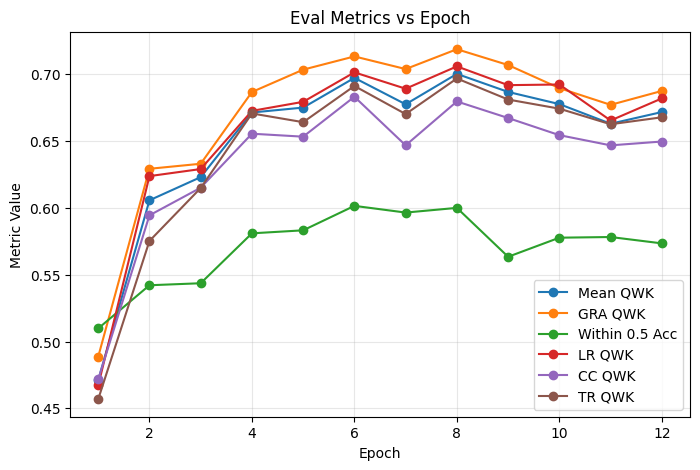

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# lấy log
log_history = trainer.state.log_history
df = pd.DataFrame(log_history)

# chỉ lấy các dòng có evaluation
eval_df = df[df["eval_mean_qwk"].notna()].copy()

# giữ metric cần
eval_df = eval_df[
    ["epoch","eval_loss","eval_mean_qwk","eval_gra_qwk","eval_within_0.5_acc","eval_lr_qwk","eval_cc_qwk","eval_tr_qwk"]
]

print(eval_df)

plt.figure(figsize=(8,5))

plt.plot(eval_df["epoch"], eval_df["eval_mean_qwk"], marker="o", label="Mean QWK")
plt.plot(eval_df["epoch"], eval_df["eval_gra_qwk"], marker="o", label="GRA QWK")
plt.plot(eval_df["epoch"], eval_df["eval_within_0.5_acc"], marker="o", label="Within 0.5 Acc")
plt.plot(eval_df["epoch"], eval_df["eval_lr_qwk"], marker="o", label="LR QWK")
plt.plot(eval_df["epoch"], eval_df["eval_cc_qwk"], marker="o", label="CC QWK")
plt.plot(eval_df["epoch"], eval_df["eval_tr_qwk"], marker="o", label="TR QWK")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("Eval Metrics vs Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

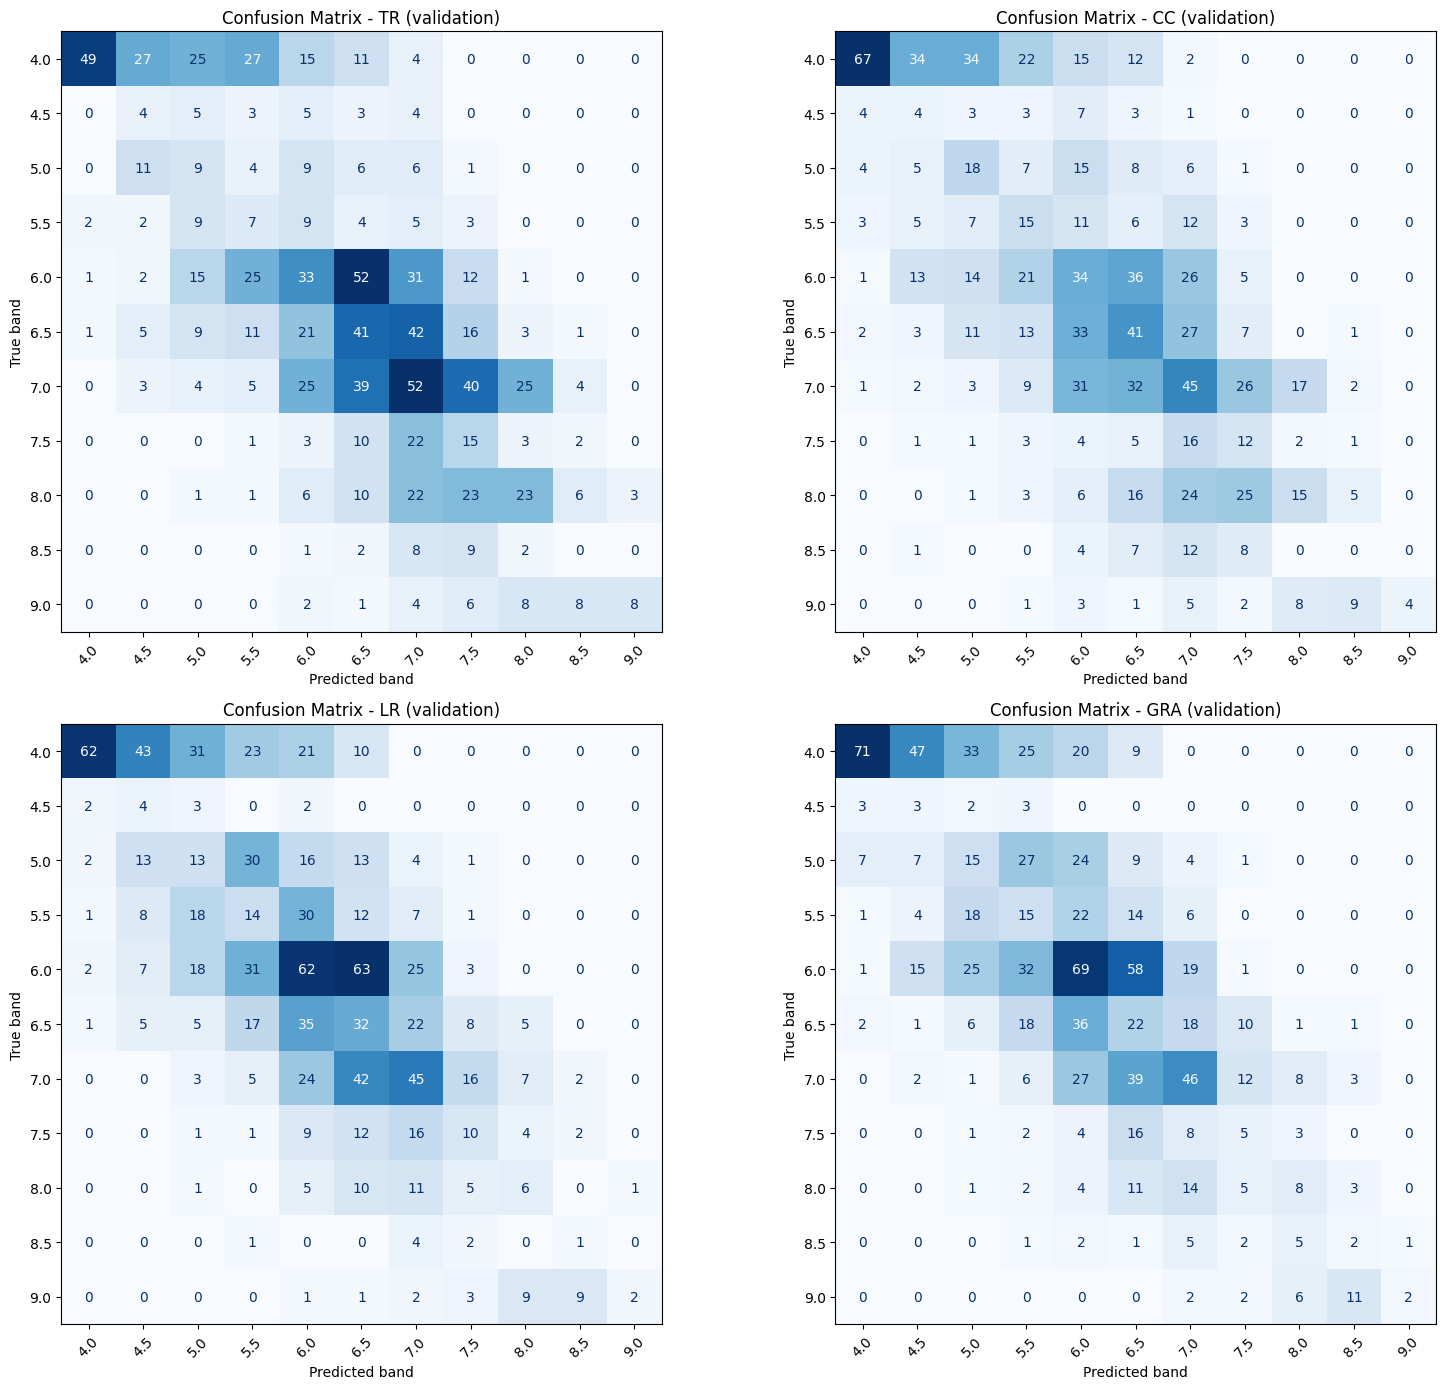


===== TR =====
True distribution:
TR_true
4.0    158
4.5     24
5.0     46
5.5     41
6.0    172
6.5    150
7.0    197
7.5     56
8.0     95
8.5     22
9.0     37
Name: count, dtype: int64

Pred distribution:
TR_pred
4.0     53
4.5     54
5.0     77
5.5     84
6.0    129
6.5    179
7.0    200
7.5    125
8.0     65
8.5     21
9.0     11
Name: count, dtype: int64

===== CC =====
True distribution:
CC_true
4.0    186
4.5     25
5.0     64
5.5     62
6.0    150
6.5    138
7.0    168
7.5     45
8.0     95
8.5     32
9.0     33
Name: count, dtype: int64

Pred distribution:
CC_pred
4.0     82
4.5     68
5.0     92
5.5     97
6.0    163
6.5    167
7.0    176
7.5     89
8.0     42
8.5     18
9.0      4
Name: count, dtype: int64

===== LR =====
True distribution:
LR_true
4.0    190
4.5     11
5.0     92
5.5     91
6.0    211
6.5    130
7.0    144
7.5     55
8.0     39
8.5      8
9.0     27
Name: count, dtype: int64

Pred distribution:
LR_pred
4.0     70
4.5     80
5.0     93
5.5    122
6.0    2

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================
# 1) Chọn split để evaluate
# =========================

eval_split = "validation"
eval_df_used = val_df.copy()

# =========================
# 2) Predict
# =========================
pred_output = trainer.predict(tokenized_ds[eval_split])
preds = pred_output.predictions
labels = pred_output.label_ids

if isinstance(preds, tuple):
    preds = preds[0]

preds = np.asarray(preds, dtype=np.float32)
labels = np.asarray(labels, dtype=np.float32)

# =========================
# 3) Nếu labels đang scale 0..1 thì đưa về band thật
# =========================
def maybe_rescale_to_band(x, score_min, score_max):
    x = np.asarray(x, dtype=np.float32)
    # nếu toàn bộ nằm trong khoảng gần 0..1 thì coi là normalized
    if np.nanmax(x) <= 1.0001 and np.nanmin(x) >= -0.0001:
        x = x * (score_max - score_min) + score_min
    return x

preds = maybe_rescale_to_band(preds, SCORE_MIN, SCORE_MAX)
labels = maybe_rescale_to_band(labels, SCORE_MIN, SCORE_MAX)

# =========================
# 4) Clip + round về 0.5 band
# =========================
preds = np.clip(preds, SCORE_MIN, SCORE_MAX)
labels = np.clip(labels, SCORE_MIN, SCORE_MAX)

preds_half = np.round(preds * 2) / 2
labels_half = np.round(labels * 2) / 2

# =========================
# 5) Tạo danh sách band chuẩn
# =========================
band_values = np.arange(SCORE_MIN, SCORE_MAX + 0.5, 0.5)
band_str = [f"{b:.1f}" for b in band_values]

# map band float -> class index integer
band_to_idx = {float(b): idx for idx, b in enumerate(band_values)}

def bands_to_indices(arr, band_values, band_to_idx):
    arr = np.asarray(arr, dtype=np.float32)
    arr = np.clip(arr, band_values.min(), band_values.max())
    arr = np.round(arr * 2) / 2
    return np.array([band_to_idx[float(x)] for x in arr], dtype=np.int64)

# =========================
# 6) Vẽ confusion matrix
# =========================
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, crit in enumerate(TARGET_COLS):
    y_true_band = labels_half[:, i]
    y_pred_band = preds_half[:, i]

    y_true_idx = bands_to_indices(y_true_band, band_values, band_to_idx)
    y_pred_idx = bands_to_indices(y_pred_band, band_values, band_to_idx)

    cm = confusion_matrix(
        y_true_idx,
        y_pred_idx,
        labels=np.arange(len(band_values))
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=band_str
    )
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False, values_format="d")

    axes[i].set_title(f"Confusion Matrix - {crit} ({eval_split})")
    axes[i].set_xlabel("Predicted band")
    axes[i].set_ylabel("True band")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# =========================
# 7) In thêm distribution
# =========================
for i, crit in enumerate(TARGET_COLS):
    print(f"\n===== {crit} =====")
    print("True distribution:")
    print(pd.Series(labels_half[:, i], name=f"{crit}_true").value_counts().sort_index())

    print("\nPred distribution:")
    print(pd.Series(preds_half[:, i], name=f"{crit}_pred").value_counts().sort_index())

In [28]:
val_metrics = trainer.evaluate(tokenized_ds["validation"])
print("Validation metrics:", val_metrics)

if "test" in tokenized_ds:
    test_metrics = trainer.evaluate(tokenized_ds["test"], metric_key_prefix="test")
    print("Test metrics:", test_metrics)

Validation metrics: {'eval_loss': 0.9143937230110168, 'eval_mean_mae': 0.7175601124763489, 'eval_mean_qwk': 0.7001563030555891, 'eval_tr_qwk': 0.6967233365089914, 'eval_cc_qwk': 0.6795377711716879, 'eval_lr_qwk': 0.7057624720050042, 'eval_gra_qwk': 0.7186016325366726, 'eval_within_0.5_acc': 0.5999498997995992, 'eval_runtime': 22.4063, 'eval_samples_per_second': 44.541, 'eval_steps_per_second': 7.453, 'epoch': 12.0}


early stopping required metric_for_best_model, but did not find eval_mean_qwk so early stopping is disabled


Test metrics: {'test_loss': 0.9779170155525208, 'test_mean_mae': 0.7412718236446381, 'test_mean_qwk': 0.5946262420796766, 'test_tr_qwk': 0.6033494205999943, 'test_cc_qwk': 0.590578428846835, 'test_lr_qwk': 0.5888773437903325, 'test_gra_qwk': 0.5956997750815447, 'test_within_0.5_acc': 0.59071072319202, 'test_runtime': 17.9088, 'test_samples_per_second': 44.782, 'test_steps_per_second': 7.482, 'epoch': 12.0}


In [ ]:
trainer.save_model(f"{OUTPUT_DIR}/best_model")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/best_model")

('./qwen25_3b_ielts_4criteria/best_model/tokenizer_config.json',
 './qwen25_3b_ielts_4criteria/best_model/chat_template.jinja',
 './qwen25_3b_ielts_4criteria/best_model/tokenizer.json')

In [ ]:
import os
import gc
import torch

# Nếu muốn train tiếp thêm, tăng tổng số epoch lên
# Ví dụ trước đó đã train 3 epoch, giờ muốn train tới epoch 6:
trainer.args.num_train_epochs = 9

# Tự tìm checkpoint mới nhất trong OUTPUT_DIR
checkpoint_dirs = [
    os.path.join(OUTPUT_DIR, d)
    for d in os.listdir(OUTPUT_DIR)
    if d.startswith("checkpoint-") and os.path.isdir(os.path.join(OUTPUT_DIR, d))
]

if not checkpoint_dirs:
    raise ValueError(f"Không tìm thấy checkpoint nào trong {OUTPUT_DIR}")

latest_checkpoint = max(checkpoint_dirs, key=lambda x: int(x.split("-")[-1]))
print("Resuming from:", latest_checkpoint)

gc.collect()
torch.cuda.empty_cache()

train_result = trainer.train(resume_from_checkpoint=latest_checkpoint)

print("Resume train xong.")
print(train_result)

In [33]:
import os
import json
import torch

EXPORT_DIR = "/content/B7_light_best_model"
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1) Lưu LoRA adapter của backbone
model.backbone.save_pretrained(EXPORT_DIR)

# 2) Lưu tokenizer
tokenizer.save_pretrained(EXPORT_DIR)

# 3) Lưu config để inference rebuild model dễ hơn
model.backbone.config.save_pretrained(EXPORT_DIR)

# 4) Lưu custom heads
head_state = {
    "tr_llm_head": model.tr_llm_head.state_dict(),
    "tr_feat_head": model.tr_feat_head.state_dict(),
    "tr_gate": model.tr_gate.state_dict(),

    "cc_llm_head": model.cc_llm_head.state_dict(),
    "cc_feat_head": model.cc_feat_head.state_dict(),
    "cc_gate": model.cc_gate.state_dict(),

    "lr_llm_head": model.lr_llm_head.state_dict(),
    "lr_feat_head": model.lr_feat_head.state_dict(),
    "lr_gate": model.lr_gate.state_dict(),

    "gra_llm_head": model.gra_llm_head.state_dict(),
    "gra_feat_head": model.gra_feat_head.state_dict(),
    "gra_gate": model.gra_gate.state_dict(),
}
torch.save(head_state, os.path.join(EXPORT_DIR, "custom_heads.pt"))

# 5) Metadata + feature stats
export_meta = {
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "head_dropout": HEAD_DROPOUT,
    "hidden_size": model.backbone.config.hidden_size,

    "target_cols": TARGET_COLS,

    "tr_feature_cols": TR_FEATURE_COLS,
    "cc_feature_cols": CC_FEATURE_COLS,
    "lr_feature_cols": LR_FEATURE_COLS,
    "gra_feature_cols": GRA_FEATURE_COLS,

    "tr_feat_mean": tr_feat_mean.tolist(),
    "tr_feat_std": tr_feat_std.tolist(),

    "cc_feat_mean": cc_feat_mean.tolist(),
    "cc_feat_std": cc_feat_std.tolist(),

    "lr_feat_mean": lr_feat_mean.tolist(),
    "lr_feat_std": lr_feat_std.tolist(),

    "gra_feat_mean": gra_feat_mean.tolist(),
    "gra_feat_std": gra_feat_std.tolist(),

    "criterion_weights": CRITERION_WEIGHTS,
    "bias_loss_weight": BIAS_LOSS_WEIGHT,

    "labels_scaled_to_1": False,
    "reg_activation": "none",
    "loss_name": "mse_plus_bias",
    "prediction_space": "band_4_9",

    # sửa cho rõ nghĩa hơn
    "fusion_type": "gated_score_fusion",
    "pooling": "last_token",
}
with open(os.path.join(EXPORT_DIR, "export_meta.json"), "w", encoding="utf-8") as f:
    json.dump(export_meta, f, ensure_ascii=False, indent=2)

print("Exported light model to:", EXPORT_DIR)

!du -sh /content/B7_light_best_model
!ls -la /content/B7_light_best_model

!zip -r /content/B7_light_best_model.zip /content/B7_light_best_model
!cp /content/B7_light_best_model.zip /content/drive/MyDrive/
print("Copied /content/B7_light_best_model.zip to Google Drive")

Exported light model to: /content/B7_light_best_model
38M	/content/B7_light_best_model
total 37972
drwxr-xr-x 2 root root     4096 Apr  5 17:47 .
drwxr-xr-x 1 root root     4096 Apr  5 17:48 ..
-rw-r--r-- 1 root root     1013 Apr  5 17:49 adapter_config.json
-rw-r--r-- 1 root root 14781920 Apr  5 17:49 adapter_model.safetensors
-rw-r--r-- 1 root root     2507 Apr  5 17:49 chat_template.jinja
-rw-r--r-- 1 root root     1552 Apr  5 17:49 config.json
-rw-r--r-- 1 root root 12636769 Apr  5 17:49 custom_heads.pt
-rw-r--r-- 1 root root     3052 Apr  5 17:49 export_meta.json
-rw-r--r-- 1 root root     5172 Apr  5 17:49 README.md
-rw-r--r-- 1 root root      665 Apr  5 17:49 tokenizer_config.json
-rw-r--r-- 1 root root 11421991 Apr  5 17:49 tokenizer.json
updating: content/B7_light_best_model/ (stored 0%)
updating: content/B7_light_best_model/adapter_config.json (deflated 57%)
updating: content/B7_light_best_model/README.md (deflated 66%)
updating: content/B7_light_best_model/custom_heads.pt (d